使用设备: cuda
训练和测试数据加载成功。
训练数据点数: 48000, 测试数据点数: 15456
数据集大小: 训练集=40147, 验证集=7085, 测试集=14688
模型参数量: 3.10M


Epoch 1/5: 100%|██████████| 628/628 [01:27<00:00,  7.17it/s]


保存最佳模型，验证损失: 0.001646
Epoch 1/5 - 训练损失: 0.004977, 验证损失: 0.001646


Epoch 2/5: 100%|██████████| 628/628 [01:26<00:00,  7.22it/s]


保存最佳模型，验证损失: 0.000937
Epoch 2/5 - 训练损失: 0.001390, 验证损失: 0.000937


...

Epoch 4/5: 100%|██████████| 628/628 [01:31<00:00,  6.85it/s]


保存最佳模型，验证损失: 0.000438
Epoch 4/5 - 训练损失: 0.000603, 验证损失: 0.000438


Epoch 5/5: 100%|██████████| 628/628 [01:33<00:00,  6.70it/s]


Epoch 5/5 - 训练损失: 0.000455, 验证损失: 0.000515


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:224: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.savefig('training_loss.png', dpi=300)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:224: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.savefig('training_loss.png', dpi=300)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:224: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.savefig('training_loss.png', dpi=300)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:224: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.savefig('training_loss.png', dpi=300)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:224: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(

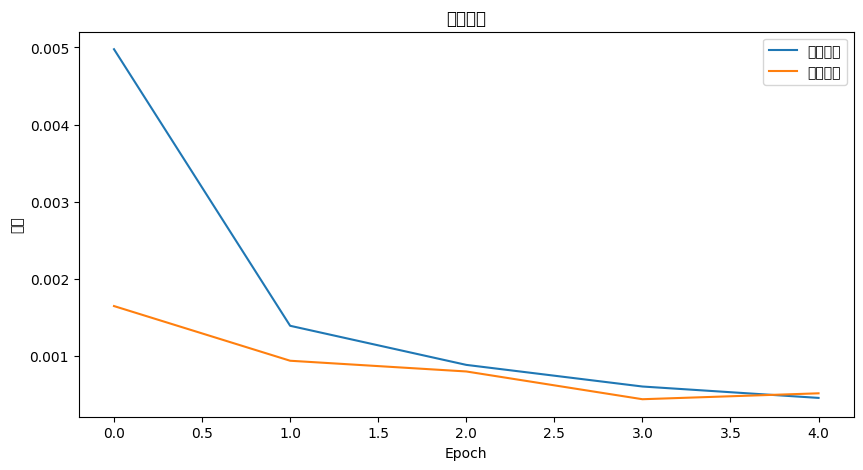

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:415: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))

训练时间: 471.55秒
测试集性能:
MAE: 0.0456
RMSE: 0.0682
MAPE: 6.07%


C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:278: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:278: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:278: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:278: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_9488\2676899994.py:278: UserWarning: Glyph 38047 (\N{CJK UNIFIED IDEOGRAPH-949F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_948

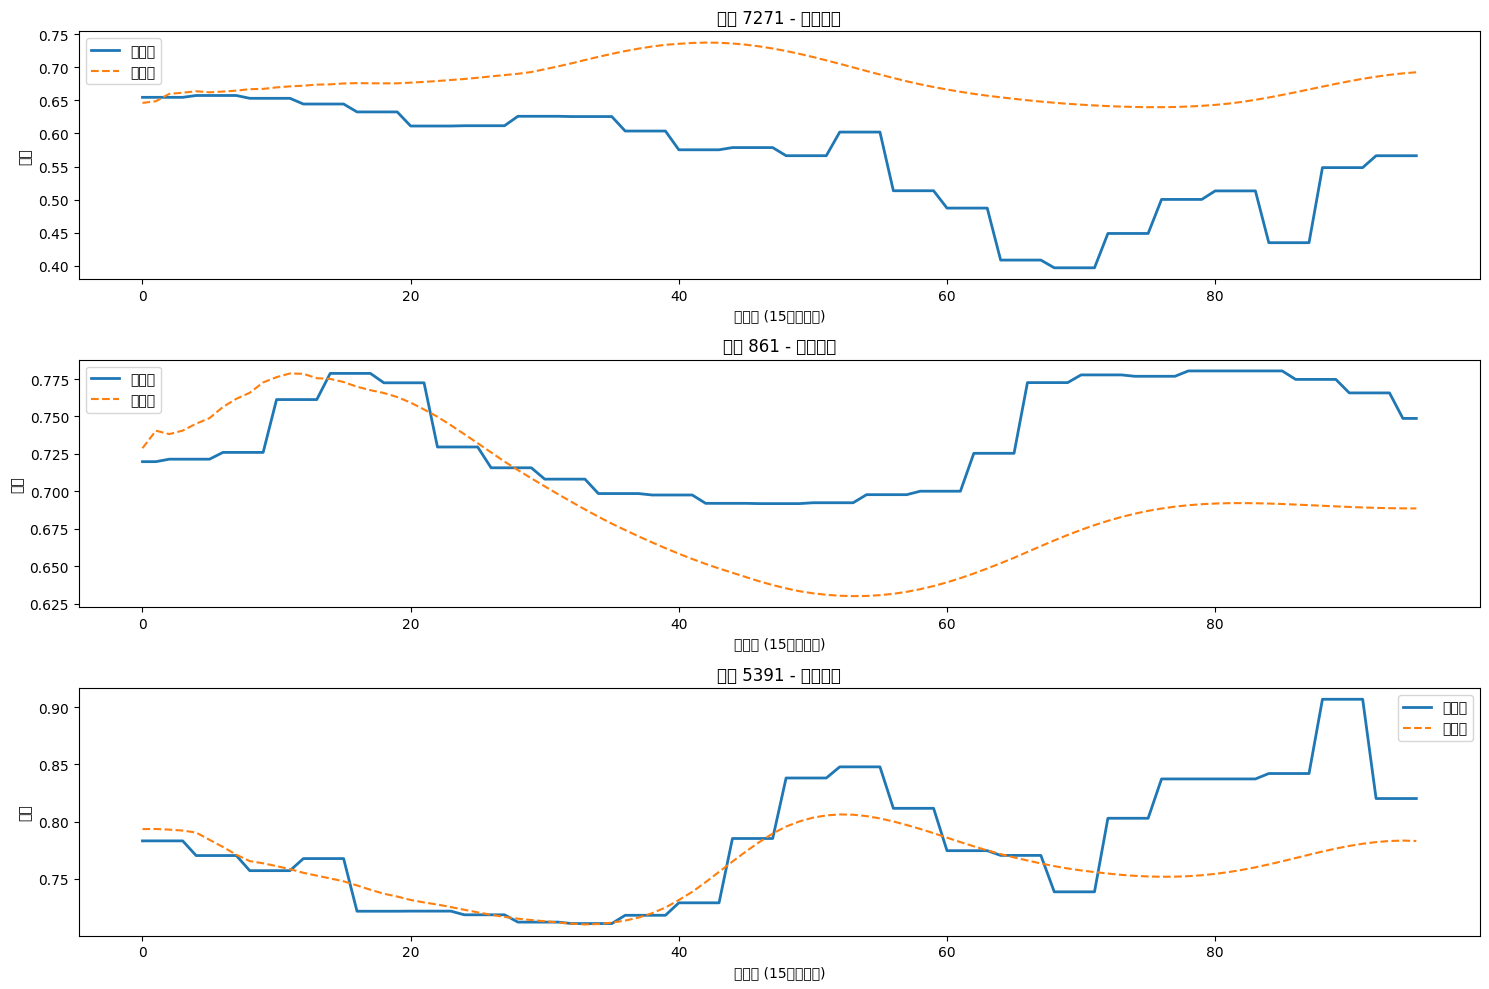

ValueError: could not broadcast input array from shape (96,1) into shape (96,)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import holidays
import time
import os
from tqdm import tqdm

# 设置随机种子保证可复现性
torch.manual_seed(42)
np.random.seed(42)

# 检查GPU可用性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

# --------------------------
# 1. 数据预处理与加载
# --------------------------

class ElectricityPriceDataset(Dataset):
    def __init__(self, data, hist_size=672, future_size=96, feature_dim=5):
        """
        电价数据集类
        
        参数:
        data: 原始电价数据 (形状: [总时间点, ])
        hist_size: 历史数据点数 (7天 = 7 * 96=672)
        future_size: 预测未来点数 (1天=96)
        feature_dim: 特征维度
        """
        self.data = data
        self.hist_size = hist_size
        self.future_size = future_size
        self.feature_dim = feature_dim
        self.samples = self._create_samples()
        
    def _create_samples(self):
        """创建时间序列样本"""
        samples = []
        total_points = len(self.data)
        
        # 生成时间特征
        timestamps = np.arange(total_points)
        hours = (timestamps % 24) / 24.0
        weekdays = ((timestamps // 24) % 7) / 7.0
        
        # 生成节假日特征（示例国家为中国）
        china_holidays = holidays.CountryHoliday('CN')
        holiday_flags = np.array([1 if pd.Timestamp('2020-01-01') + pd.Timedelta(days=int(i/96)) in china_holidays else 0 
                                 for i in range(total_points)])
        
        # 构建特征矩阵
        features = np.zeros((total_points, self.feature_dim))
        features[:, 0] = self.data  # 电价
        features[:, 1] = hours     # 小时
        features[:, 2] = weekdays  # 星期
        features[:, 3] = holiday_flags  # 节假日
        # 第4个特征留作扩展（如温度、负荷等）
        
        # 创建滑动窗口样本
        for i in range(self.hist_size, total_points - self.future_size):
            hist_features = features[i-self.hist_size:i]
            target = self.data[i:i+self.future_size]
            samples.append((hist_features, target))
            
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        hist, target = self.samples[idx]
        return torch.tensor(hist, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

# --------------------------
# 2. 模型架构
# --------------------------

class TCNBlock(nn.Module):
    """时间卷积网络块"""
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, out_channels, kernel_size, 
                             padding=(kernel_size-1)*dilation, dilation=dilation)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.norm = nn.BatchNorm1d(out_channels)
        
    def forward(self, x):
        return self.dropout(self.norm(self.relu(self.conv(x))))

class TCN_Seq2Seq(nn.Module):
    """TCN-Seq2Seq电价预测模型"""
    def __init__(self, input_size=5, output_size=1, hist_size=672, kernel_size=5):
        super().__init__()
        self.hist_size = hist_size
        
        # TCN编码器
        self.tcn = nn.Sequential(
            TCNBlock(input_size, 64, kernel_size, dilation=1),
            TCNBlock(64, 128, kernel_size, dilation=2),
            TCNBlock(128, 256, kernel_size, dilation=4),
            TCNBlock(256, 256, kernel_size, dilation=8)
        )
        
        # GRU编码器-解码器
        self.encoder = nn.GRU(256, 512, batch_first=True)
        self.decoder = nn.GRU(256, 512, batch_first=True)
        
        # 添加一个投影层，将解码器输出映射回输入维度
        self.input_proj = nn.Linear(512, 256)

        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
        
    def forward(self, x, future=96):
        # 输入形状: [batch, hist_size, features]
        batch_size = x.size(0)
        
        # TCN特征提取
        x = x.permute(0, 2, 1)  # [batch, features, hist_size]
        tcn_out = self.tcn(x)  # [batch, channels, hist_size]
        tcn_out = tcn_out.permute(0, 2, 1)  # [batch, hist_size, channels]
        
        # 编码器处理历史数据
        _, hidden = self.encoder(tcn_out)
        
        # 解码器逐步预测
        outputs = []
        dec_input = tcn_out[:, -1:, :]  # 最后时刻作为初始输入
        
        for _ in range(future):
            out, hidden = self.decoder(dec_input, hidden)
            pred = self.fc(out)
            outputs.append(pred)
            
            # 准备下一个解码器输入：将当前解码器输出投影回输入维度
            dec_input = self.input_proj(out)
        
        return torch.cat(outputs, dim=1)  # [batch, future, 1]

# --------------------------
# 3. 训练函数
# --------------------------

def train_model(model, train_loader, val_loader, epochs=100, lr=0.001):
    """模型训练函数"""
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
    
    # 自定义损失函数（对高价时段增加权重）
    def weighted_mse_loss(pred, target):
        # 下午高峰时段（16-20点）权重更高
        weights = torch.ones_like(target)
        peak_hours = torch.arange(target.size(1)) % 96
        peak_mask = (peak_hours >= 16 * 4) & (peak_hours < 20 * 4)  # 每15分钟一个点
        weights[:, peak_mask] = 2.0
        return torch.mean(weights * (pred - target) ** 2)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # 训练阶段
        model.train()
        train_loss = 0
        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, targets = inputs.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = weighted_mse_loss(outputs.squeeze(-1), targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
        
        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)
        
        # 验证阶段
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = weighted_mse_loss(outputs.squeeze(-1), targets)
                val_loss += loss.item() * inputs.size(0)
        
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        
        # 保存最佳模型
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"保存最佳模型，验证损失: {val_loss:.6f}")
        
        print(f"Epoch {epoch+1}/{epochs} - 训练损失: {train_loss:.6f}, 验证损失: {val_loss:.6f}")
    
    # 绘制损失曲线
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='训练损失')
    plt.plot(val_losses, label='验证损失')
    plt.xlabel('Epoch')
    plt.ylabel('损失')
    plt.legend()
    plt.title('训练过程')
    plt.savefig('training_loss.png', dpi=300)
    plt.show()
    
    return train_losses, val_losses

# --------------------------
# 4. 评估函数
# --------------------------

def evaluate_model(model, test_loader):
    """模型评估函数"""
    model.eval()
    actuals, predictions = [], []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs).squeeze(-1).cpu().numpy()
            
            actuals.append(targets.cpu().numpy())
            predictions.append(outputs)
    
    actuals = np.vstack(actuals)
    predictions = np.vstack(predictions)
    
    # 计算指标
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    
    print(f"测试集性能:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")
    
    # 绘制预测示例
    plot_predictions(actuals, predictions)
    
    return actuals, predictions, (mae, rmse, mape)

def plot_predictions(actuals, predictions, num_samples=3):
    """绘制预测结果示例"""
    plt.figure(figsize=(15, 10))
    
    for i in range(num_samples):
        idx = np.random.randint(0, len(actuals))
        plt.subplot(num_samples, 1, i+1)
        plt.plot(actuals[idx], label='实际值', linewidth=2)
        plt.plot(predictions[idx], label='预测值', linestyle='--')
        plt.title(f'样本 {idx+1} - 电价预测')
        plt.xlabel('时间点 (15分钟间隔)')
        plt.ylabel('电价')
        plt.legend()
    
    plt.tight_layout()
    plt.savefig('predictions_example.png', dpi=300)
    plt.show()

# --------------------------
# 5. 预测函数
# --------------------------

def progressive_forecast(model, initial_data, days=7):
    """
    渐进式多日预测
    
    参数:
    model: 训练好的模型
    initial_data: 初始输入数据 [hist_size, features]
    days: 预测天数
    
    返回:
    forecast: 预测结果 [days*96, ]
    """
    model.eval()
    model.to(device)
    
    # 初始化
    current_input = torch.tensor(initial_data, dtype=torch.float32).unsqueeze(0).to(device)
    full_forecast = []
    
    for day in range(days):
        with torch.no_grad():
            # 预测未来一天
            pred = model(current_input).squeeze(0).cpu().numpy()
            full_forecast.append(pred)
            
            # 更新输入数据（移除最旧的一天，添加最新预测）
            if day < days - 1:
                # 更新特征矩阵
                new_input = current_input.cpu().numpy().squeeze(0)
                
                # 移除最旧的一天 (96个点)
                new_input = new_input[96:]
                
                # 添加预测结果作为新的电价数据
                new_price = pred
                
                # 更新时间特征
                last_timestamp = new_input[-1, 1] * 24  # 最后时间点的小时
                new_hours = np.arange(last_timestamp + 1/96, last_timestamp + 1, 1/96) % 24 / 24.0
                new_weekdays = ((np.arange(len(new_price)) // 96 + 
                                int(new_input[-1, 2] * 7)) % 7) / 7.0
                
                # 构建新特征
                new_features = np.zeros((96, new_input.shape[1]))
                new_features[:, 0] = new_price
                new_features[:, 1] = new_hours
                new_features[:, 2] = new_weekdays
                # 节假日特征保持不变（需要实际实现）
                
                # 组合新输入
                new_input = np.vstack([new_input, new_features])
                current_input = torch.tensor(new_input, dtype=torch.float32).unsqueeze(0).to(device)
    
    return np.concatenate(full_forecast)

# --------------------------
# 6. 主函数
# --------------------------

def main():
    # --- 1. 加载并准备数据 ---
    # 定义数据文件路径 (假设在上一级目录的'data'文件夹中)
    from pathlib import Path
    data_path = Path.cwd().parent / 'data'
    train_file = data_path / 'train_prices.csv'
    test_file = data_path / 'test_prices.csv'

    try:
        # 加载训练数据并提取最后一列
        train_df = pd.read_csv(train_file)
        train_prices = train_df.iloc[:, -1].values

        # 加载测试数据并提取最后一列
        test_df = pd.read_csv(test_file)
        test_prices = test_df.iloc[:, -1].values
        print("训练和测试数据加载成功。")
        print(f"训练数据点数: {len(train_prices)}, 测试数据点数: {len(test_prices)}")
    except FileNotFoundError as e:
        print(f"错误: 找不到数据文件 {e}。请确保 'data/train_prices.csv' 和 'data/test_prices.csv' 存在。")
        return
    except Exception as e:
        print(f"加载数据时出错: {e}")
        return

    # --- 2. 数据归一化 ---
    # 仅使用训练数据来拟合归一化模型，以防数据泄露
    scaler = MinMaxScaler()
    scaled_train_prices = scaler.fit_transform(train_prices.reshape(-1, 1)).flatten()
    # 使用相同的归一化模型转换测试数据
    scaled_test_prices = scaler.transform(test_prices.reshape(-1, 1)).flatten()

    # --- 3. 创建数据集和数据加载器 ---
    points_per_day = 96
    hist_size = 7 * points_per_day  # 7天历史数据
    future_size = points_per_day    # 预测1天
    
    # 为训练和验证创建数据集
    full_train_dataset = ElectricityPriceDataset(scaled_train_prices, hist_size, future_size)
    
    # 将训练数据集划分为训练集和验证集 (例如 85% 训练, 15% 验证)
    train_size = int(0.85 * len(full_train_dataset))
    val_size = len(full_train_dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(
        full_train_dataset, [train_size, val_size]
    )
    
    # 为测试创建数据集
    test_dataset = ElectricityPriceDataset(scaled_test_prices, hist_size, future_size)

    # 创建数据加载器
    batch_size = 64
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    print(f"数据集大小: 训练集={len(train_dataset)}, 验证集={len(val_dataset)}, 测试集={len(test_dataset)}")
    
    # --- 4. 初始化和训练模型 ---
    model = TCN_Seq2Seq(input_size=5, hist_size=hist_size)
    print(f"模型参数量: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
    
    start_time = time.time()
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, epochs=5, lr=0.001
    )
    print(f"训练时间: {time.time()-start_time:.2f}秒")
    
    # --- 5. 评估和预测 ---
    # 加载性能最佳的模型
    model.load_state_dict(torch.load('best_model.pth'))
    
    # 在测试集上评估模型
    actuals, predictions, metrics = evaluate_model(model, test_loader)
    
    # 反归一化以查看真实数值
    actuals = scaler.inverse_transform(actuals.reshape(-1, 1)).reshape(actuals.shape)
    predictions = scaler.inverse_transform(predictions.reshape(-1, 1)).reshape(predictions.shape)
    
    # 示例：使用测试集中的一个样本进行渐进式预测
    if len(test_dataset) > 0:
        test_sample_idx = np.random.randint(0, len(test_dataset))
        test_input, _ = test_dataset[test_sample_idx]
        
        # 预测未来7天
        forecast = progressive_forecast(model, test_input.numpy(), days=7)
        forecast = scaler.inverse_transform(forecast.reshape(-1, 1)).flatten()
        
        # 绘制长期预测图
        plt.figure(figsize=(15, 6))
        plt.plot(forecast, label='预测电价', linewidth=2)
        plt.title('未来7天电价预测')
        plt.xlabel('时间点 (15分钟间隔)')
        plt.ylabel('电价')
        plt.grid(True)
        plt.legend()
        plt.savefig('long_term_forecast.png', dpi=300)
        plt.show()
    else:
        print("测试集为空，无法进行渐进式预测。")

if __name__ == "__main__":
    main()